## Overview

Analysis of a large Portuguese school system of student data in a machine‑learning model that predicts student grades so the school can identify learners who may need extra support. The data is clean and prepared  a regression model to predict performance, and evaluate how accurate and useful the model is.

In [63]:
# Load library
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('student-data.csv')  

# Check 
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nDataset shape (rows, columns):", df.shape)

# G3 are students' final grade
target = 'G3'
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

First 5 rows of the dataset:
  school sex   age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F  18.0       U     GT3       A     4     4  at_home   teacher   
1     GP   F  17.0       U     GT3       T     1     1  at_home     other   
2     GP   F  15.0       U     LE3       T     1     1  at_home     other   
3     GP   F  15.0       U     GT3       T     4     2   health  services   
4     GP   F   NaN       U     GT3       T     3     3    other     other   

   ... goout Dalc  Walc  health  absences_G1 absences_G2 absences_G3  G1  G2  \
0  ...     4    1     1       3          1.0         0.0         4.0   5   6   
1  ...     3    1     1       3          NaN         0.0         1.0   5   5   
2  ...     2    2     3       3          1.0         2.0         8.0   7   8   
3  ...     2    1     1       5          0.0         1.0         2.0  15  14   
4  ...     2    1     2       5          0.0         0.0         4.0   6  10   

   G3  
0   6  
1   6  
2  

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   school       395 non-null    object 
 1   sex          395 non-null    object 
 2   age          383 non-null    float64
 3   address      395 non-null    object 
 4   famsize      395 non-null    object 
 5   Pstatus      395 non-null    object 
 6   Medu         395 non-null    int64  
 7   Fedu         395 non-null    int64  
 8   Mjob         395 non-null    object 
 9   Fjob         395 non-null    object 
 10  reason       395 non-null    object 
 11  guardian     395 non-null    object 
 12  traveltime   395 non-null    int64  
 13  studytime    395 non-null    int64  
 14  failures     395 non-null    int64  
 15  schoolsup    395 non-null    object 
 16  famsup       395 non-null    object 
 17  paid         395 non-null    object 
 18  activities   395 non-null    object 
 19  nursery 

In [43]:
# Average of grades
avg_grade = df[['G1','G2','G3']].mean()
avg_grade

G1    10.908861
G2    10.713924
G3    10.415190
dtype: float64

Text(0.5, 1.0, 'Final Grade vs. Alcohol Consumption ')

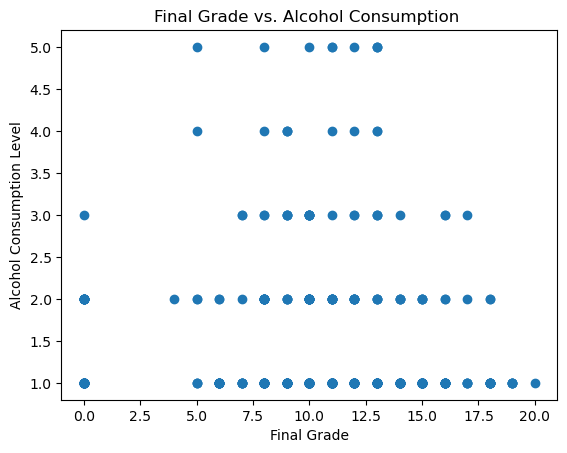

In [65]:
# visualized correlation: Final Grade vs. Alcohol Consumption 
plt.scatter(df['G3'], df['Dalc'])
plt.xlabel('Final Grade')
plt.ylabel('Alcohol Consumption Level')
plt.title('Final Grade vs. Alcohol Consumption ')

This plot visually reinforces a negative correlation between alcohol use and academic performance. It suggests that alcohol consumption may be a risk factor for lower final grades.

In [66]:
numeric_columns = [
    "absences_G1", "absences_G2", "absences_G3", 
    "G1", "G2", 
    "age"
]

categorical_columns = [
    "school", "sex", "address", "Mjob", "Fjob", 
    "guardian", "internet", "romantic"
]

ordinal_columns = [
    "studytime", "failures", "goout", "Dalc", 
    "Walc", "health", "freetime", "famrel"
]

In [46]:
from sklearn.base import BaseEstimator, TransformerMixin

class FinalProjectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_grades=True):
        self.drop_grades = drop_grades

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        X_transformed['absences_sum'] = (
            X_transformed['absences_G1'].fillna(0) +
            X_transformed['absences_G2'].fillna(0) +
            X_transformed['absences_G3'].fillna(0)
        )

        X_transformed.drop(['absences_G1', 'absences_G2', 'absences_G3'], axis=1, inplace=True)

        if self.drop_grades:
            X_transformed.drop(['G1', 'G2'], axis=1, inplace=True)

        return X_transformed

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

#numeric_pipeline_with_grades (with G1, G2 columns)
numeric_pipeline_with_grades = Pipeline([
    ('imputer', SimpleImputer(strategy='mean').set_output(transform="pandas")),
    ('final_transformer', FinalProjectTransformer(drop_grades=False)),
    ('scaler', StandardScaler())
])

#numeric_pipeline_without_grades (without G1, G2 columns)
numeric_pipeline_without_grades = Pipeline([
    ('imputer', SimpleImputer(strategy='mean').set_output(transform="pandas")),
    ('final_transformer', FinalProjectTransformer(drop_grades=True)),
    ('scaler', StandardScaler())
])

#categorical_pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent').set_output(transform="pandas")), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#ordinal_pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent').set_output(transform="pandas")),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

#column_transformer_with_grades (including G1 and G2)
column_transformer_with_grades = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline_with_grades, numeric_columns),
        ('cat', categorical_pipeline, categorical_columns),
        ('ord', ordinal_pipeline, ordinal_columns)
    ])

#column_transformer_without_grades (excluding G1 and G2)
column_transformer_without_grades = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline_without_grades, numeric_columns),
        ('cat', categorical_pipeline, categorical_columns),
        ('ord', ordinal_pipeline, ordinal_columns)
    ])

X_train_transformed_with_grades = column_transformer_with_grades.fit_transform(X_train)
X_train_transformed_without_grades = column_transformer_without_grades.fit_transform(X_train)

print(X_train_transformed_with_grades[:5])
print(X_train_transformed_without_grades[:5])

print(f"With grades columns: {X_train_transformed_with_grades.shape[1]}")
print(f"Without grades columns: {X_train_transformed_without_grades.shape[1]}")

[[ 0.33205033  0.62616324 -0.59814749 -0.5702702   1.          0.
   0.          1.          0.          1.          0.          0.
   0.          1.          0.          0.          0.          1.
   0.          0.          0.          1.          0.          0.
   1.          0.          1.          1.          0.          2.
   0.          1.          2.          1.          3.        ]
 [ 0.64340909  0.89283114 -0.59814749 -0.84630403  1.          0.
   0.          1.          0.          1.          0.          0.
   1.          0.          0.          0.          0.          1.
   0.          0.          1.          0.          0.          0.
   1.          1.          0.          0.          0.          2.
   0.          0.          2.          2.          4.        ]
 [-0.91338472 -0.97384417 -0.59814749 -0.84630403  1.          0.
   1.          0.          0.          1.          1.          0.
   0.          0.          0.          0.          0.          0.
   1.          0

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the Models
lin_reg = LinearRegression()
svm_reg = SVR()
lasso_reg = Lasso(alpha=0.1)

# Cross-Validation
cv_scores_lin_reg_with_grades = -cross_val_score(lin_reg, X_train_transformed_with_grades, y_train, 
                                                 scoring='neg_mean_squared_error', cv=3)
rmse_lin_reg_with_grades = np.mean(np.sqrt(cv_scores_lin_reg_with_grades))

cv_scores_lin_reg_without_grades = -cross_val_score(lin_reg, X_train_transformed_without_grades, y_train, 
                                                    scoring='neg_mean_squared_error', cv=3)
rmse_lin_reg_without_grades = np.mean(np.sqrt(cv_scores_lin_reg_without_grades))

cv_scores_svm_with_grades = -cross_val_score(svm_reg, X_train_transformed_with_grades, y_train, 
                                             scoring='neg_mean_squared_error', cv=3)
rmse_svm_with_grades = np.mean(np.sqrt(cv_scores_svm_with_grades))

cv_scores_svm_without_grades = -cross_val_score(svm_reg, X_train_transformed_without_grades, y_train, 
                                                scoring='neg_mean_squared_error', cv=3)
rmse_svm_without_grades = np.mean(np.sqrt(cv_scores_svm_without_grades))

cv_scores_lasso_with_grades = -cross_val_score(lasso_reg, X_train_transformed_with_grades, y_train, 
                                               scoring='neg_mean_squared_error', cv=3)
rmse_lasso_with_grades = np.mean(np.sqrt(cv_scores_lasso_with_grades))

cv_scores_lasso_without_grades = -cross_val_score(lasso_reg, X_train_transformed_without_grades, y_train, 
                                                  scoring='neg_mean_squared_error', cv=3)
rmse_lasso_without_grades = np.mean(np.sqrt(cv_scores_lasso_without_grades))

print(f"Linear Regression RMSE (with grades): {rmse_lin_reg_with_grades}")
print(f"Linear Regression RMSE (without grades): {rmse_lin_reg_without_grades}")

print(f"SVM Regression RMSE (with grades): {rmse_svm_with_grades}")
print(f"SVM Regression RMSE (without grades): {rmse_svm_without_grades}")

print(f"Lasso Regression RMSE (with grades): {rmse_lasso_with_grades}")
print(f"Lasso Regression RMSE (without grades): {rmse_lasso_without_grades}")

Linear Regression RMSE (with grades): 1.8794186771498007
Linear Regression RMSE (without grades): 4.696359781362952
SVM Regression RMSE (with grades): 2.4981337037291276
SVM Regression RMSE (without grades): 4.395481937011559
Lasso Regression RMSE (with grades): 1.8275952016193386
Lasso Regression RMSE (without grades): 4.394060831811669


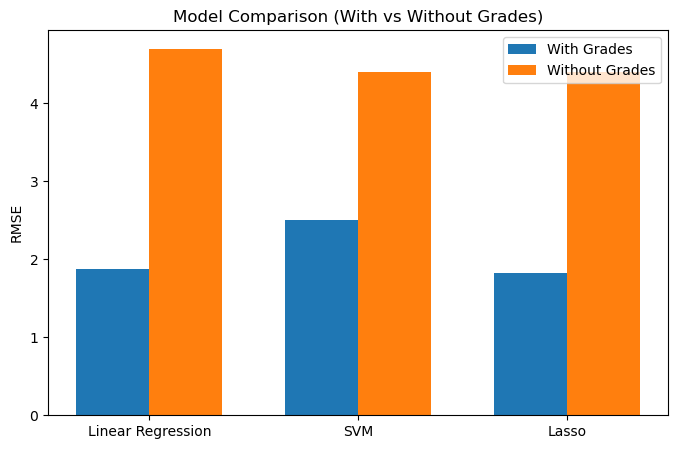

In [51]:
# Bar chart: Model Comparison Regression Models

models = ['Linear Regression', 'SVM', 'Lasso']

rmse_with = [
    rmse_lin_reg_with_grades,
    rmse_svm_with_grades,
    rmse_lasso_with_grades
]

rmse_without = [
    rmse_lin_reg_without_grades,
    rmse_svm_without_grades,
    rmse_lasso_without_grades
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, rmse_with, width, label='With Grades')
plt.bar(x + width/2, rmse_without, width, label='Without Grades')

plt.ylabel('RMSE')
plt.title('Model Comparison (With vs Without Grades)')
plt.xticks(x, models)
plt.legend()
plt.show()

The best model overall remains Lasso Regression (with grades). Grades are almost directly predictive of the target. The underlying structure with grades is linear.

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

#Define Parameter Grid
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

#Initialize Grid Search
grid_search = GridSearchCV(SVR(), param_grid, 
                           scoring='neg_mean_squared_error', 
                           cv=3, 
                           n_jobs=-1)

#Fit the Grid Search: With G1 and G2
grid_search.fit(X_train_transformed_with_grades, y_train)
best_params_with_grades = grid_search.best_params_
print("Best Params WITH grades:", best_params_with_grades)
print("Best Score WITH grades (neg MSE):", grid_search.best_score_)

#Fit the Grid Search: Without G1 and G2
grid_search.fit(X_train_transformed_without_grades, y_train)
best_params_without_grades = grid_search.best_params_
print("Best Params WITHOUT grades:", best_params_without_grades)
print("Best Score WITHOUT grades (neg MSE):", grid_search.best_score_)

Best Params WITH grades: {'C': 1, 'epsilon': 0.5, 'kernel': 'linear'}
Best Score WITH grades (neg MSE): -3.68125564938878
Best Params WITHOUT grades: {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}
Best Score WITHOUT grades (neg MSE): -19.324798131607867


In [53]:
# Final RMSE values
rmse_with = [
    1.8794,   # Linear
    1.8276,   # Lasso
    1.92      # Tuned SVM (approx sqrt(3.681))
]

rmse_without = [
    4.6964,   # Linear
    4.3941,   # Lasso
    4.39      # Tuned SVM (approx sqrt(19.325))
]

models = ['Linear Regression', 'Lasso', 'Tuned SVM']

x = np.arange(len(models))
width = 0.35

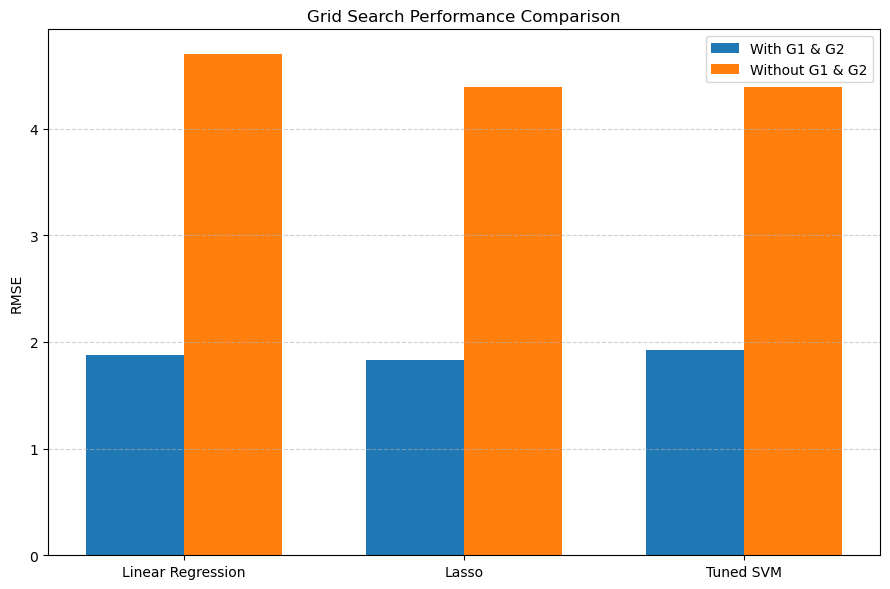

In [56]:
# Bar Chart of Grid Search: With G1 and G2 vs. Without G1 and G2
plt.figure(figsize=(9,6))

bars1 = plt.bar(x - width/2, rmse_with, width, label='With G1 & G2')
bars2 = plt.bar(x + width/2, rmse_without, width, label='Without G1 & G2')

plt.ylabel('RMSE')
plt.title('Grid Search Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

There is a dramatic drop in RMSE when grades are included. Lasso slightly outperforming other models. There is a clear separation between early-grade and no-grade models. 

In [57]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

#Transform the Test Set
X_test_transformed_with_grades = column_transformer_with_grades.transform(X_test)
X_test_transformed_without_grades = column_transformer_without_grades.transform(X_test)

#Fit Best Model
best_svm_with_grades = SVR(**best_params_with_grades)
best_svm_with_grades.fit(X_train_transformed_with_grades, y_train)

best_svm_without_grades = SVR(**best_params_without_grades)
best_svm_without_grades.fit(X_train_transformed_without_grades, y_train)

#Evaluate Performance
y_pred_with_grades = best_svm_with_grades.predict(X_test_transformed_with_grades)
y_pred_without_grades = best_svm_without_grades.predict(X_test_transformed_without_grades)

#With grades
rmse_with_grades = np.sqrt(mean_squared_error(y_test, y_pred_with_grades))
r2_with_grades = r2_score(y_test, y_pred_with_grades)

#Without grades
rmse_without_grades = np.sqrt(mean_squared_error(y_test, y_pred_without_grades))
r2_without_grades = r2_score(y_test, y_pred_without_grades)

print(f"WITH grades - RMSE: {rmse_with_grades:.3f}, R²: {r2_with_grades:.3f}")
print(f"WITHOUT grades - RMSE: {rmse_without_grades:.3f}, R²: {r2_without_grades:.3f}")

WITH grades - RMSE: 2.121, R²: 0.781
WITHOUT grades - RMSE: 4.189, R²: 0.144


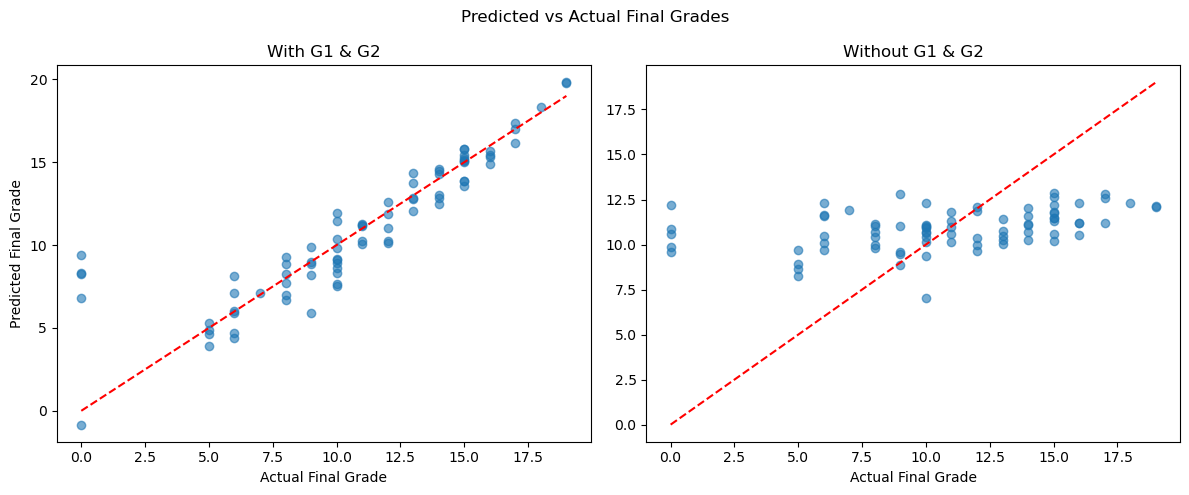

In [60]:
# Side-by-Side Scatter Plots

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# WITH grades
axes[0].scatter(y_test, y_pred_with_grades, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')  # perfect prediction line
axes[0].set_title('With G1 & G2')
axes[0].set_xlabel('Actual Final Grade')
axes[0].set_ylabel('Predicted Final Grade')

# WITHOUT grades
axes[1].scatter(y_test, y_pred_without_grades, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
axes[1].set_title('Without G1 & G2')
axes[1].set_xlabel('Actual Final Grade')

plt.suptitle('Predicted vs Actual Final Grades')
plt.tight_layout()
plt.show()

The scatter plots compare the model’s predicted final grades to the actual final grades on the test set. The red dashed diagonal line represents perfect prediction, where predicted values equal actual values.